## A simple DC motor example with two PID controllers in cascade

### L-BFGS optimization

Optimal PID params:
Pos loop:
Kp = 6.822
Ki = 0.000
Kd = 0.000

Vel loop:
Kp = 7.407
Ki = 0.000
Kd = 1.978

System performance metrics:
Steady-state err = 0.000000
Overshoot = 1.71%
2% settling time = 1.41 seconds


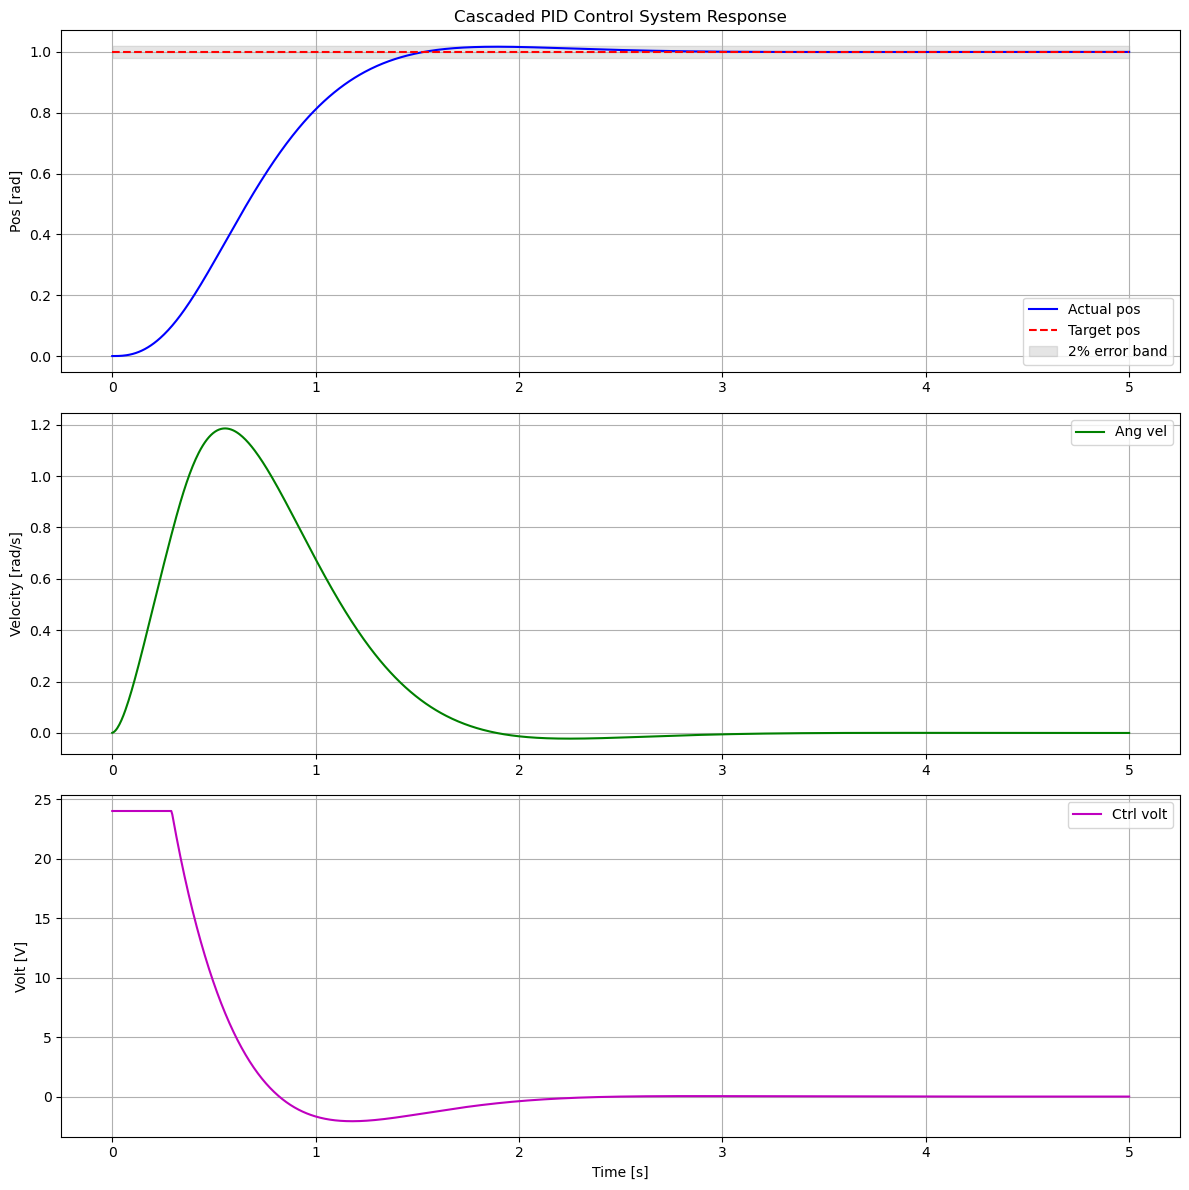

In [ ]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt


class DCMotor:
    def __init__(self, J=0.01, b=0.1, K=0.01, R=1.0, L=0.5):
        """
        DC Motor Model
        Parameters:
            J: Moment of inertia
            b: Viscous damping coefficient
            K: Motor constant (torque constant and back EMF constant)
            R: Armature resistance
            L: Armature inductance
        State variables:
            x[0]: θ (angle)
            x[1]: ω (angular velocity)
            x[2]: i (current)
        """
        self.J = J
        self.b = b
        self.K = K
        self.R = R
        self.L = L

    def dynamics(self, state, t, v):
        theta, omega, i = state
        
        # Motor dynamics equations
        dtheta = omega
        domega = (self.K * i - self.b * omega) / self.J
        di = (-self.R * i - self.K * omega + v) / self.L
        
        return [dtheta, domega, di]

class CascadedPIDController:
    def __init__(self, kp_pos, ki_pos, kd_pos, kp_vel, ki_vel, kd_vel):
        # Pos loop
        self.kp_pos = kp_pos
        self.ki_pos = ki_pos
        self.kd_pos = kd_pos
        
        # Vel loop
        self.kp_vel = kp_vel
        self.ki_vel = ki_vel
        self.kd_vel = kd_vel
        
        self.reset()
    
    def reset(self):
        # Pos loop
        self.pos_integral = 0
        self.pos_prev_error = 0
        
        # Vel loop
        self.vel_integral = 0
        self.vel_prev_error = 0
    
    def control(self, pos_ref, pos, vel, dt):
        # Pos loop control
        pos_error = pos_ref - pos
        self.pos_integral += pos_error * dt
        pos_derivative = (pos_error - self.pos_prev_error) / dt
        self.pos_prev_error = pos_error
        
        # Pos loop output as the ref input for the vel loop
        vel_ref = (self.kp_pos * pos_error + 
                  self.ki_pos * self.pos_integral + 
                  self.kd_pos * pos_derivative)
        
        # Vel loop control
        vel_error = vel_ref - vel
        self.vel_integral += vel_error * dt
        vel_derivative = (vel_error - self.vel_prev_error) / dt
        self.vel_prev_error = vel_error
        
        # Vel loop output as the voltage input
        v = (self.kp_vel * vel_error + 
             self.ki_vel * self.vel_integral + 
             self.kd_vel * vel_derivative)
        
        return np.clip(v, -24, 24)  # Limit the voltage to the range ±24V

def simulate_system(params):
    kp_pos, ki_pos, kd_pos, kp_vel, ki_vel, kd_vel = params
    
    motor = DCMotor()
    controller = CascadedPIDController(kp_pos, ki_pos, kd_pos, kp_vel, ki_vel, kd_vel)
    
    # Sim params
    t = np.linspace(0, 5, 1000)  # 5s, 1000 sample points
    dt = t[1] - t[0]
    pos_ref = 1.0  # Target position of 1 rad
    
    # Initial state [theta, omega, i]
    x0 = [0, 0, 0]
    
    pos_history = []
    vel_history = []
    v_history = []
    
    # Simulate
    x = x0
    for i in range(len(t)):
        v = controller.control(pos_ref, x[0], x[1], dt)
        x = odeint(motor.dynamics, x, [t[i], t[i] + dt], args=(v,))[-1]

        pos_history.append(x[0])
        vel_history.append(x[1])
        v_history.append(v)
    
    return t, np.array(pos_history), np.array(vel_history), np.array(v_history)

def objective(params):
    t, pos, vel, v = simulate_system(params)
    
    pos_ref = 1.0
    pos_error = pos_ref - pos
    
    # Compute performance metrics
    pos_ise = np.sum(pos_error**2)  # Integral of squared position error
    vel_smoothness = np.sum(np.diff(vel)**2)  # Smoothness of velocity
    control_effort = np.sum(v**2)  # Control effort
    
    # Steady-state error (using the average error over the last 0.5 seconds)
    steady_state_error = np.abs(np.mean(pos_error[-100:]))
    
    # Overshoot
    overshoot = np.max(np.maximum(pos - pos_ref, 0))
    
    # Combined objective function
    return (2.0 * pos_ise + 
            500.0 * steady_state_error +  # Emphasize steady-state error
            10.0 * overshoot + 
            0.01 * vel_smoothness +  # Smooth velocity response
            0.001 * control_effort)  # Control energy


# Initial params and bounds
initial_guess = [5.0, 2.0, 1.0,  # Pos loop PID
                2.0, 1.0, 0.1]  # Vel loop PID
bounds = [(0.1, 20.0), (0.0, 10.0), (0.0, 10.0),  # Pos loop PID
         (0.1, 20.0), (0.0, 10.0), (0.0, 10.0)]   # Vel loop PID

# Optimization
result = minimize(
    objective,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100}
)

# Optimal params
optimized_params = result.x
print("Optimal PID params:")
print("Pos loop:")
print(f"Kp = {optimized_params[0]:.3f}")
print(f"Ki = {optimized_params[1]:.3f}")
print(f"Kd = {optimized_params[2]:.3f}")
print("\nVel loop:")
print(f"Kp = {optimized_params[3]:.3f}")
print(f"Ki = {optimized_params[4]:.3f}")
print(f"Kd = {optimized_params[5]:.3f}")

# Simulate using the optimal params
t, pos, vel, v = simulate_system(optimized_params)

# Calculate performance metrics
pos_ref = 1.0
error = pos_ref - pos
steady_state_err = np.abs(np.mean(error[-100:]))
overshoot = np.max(np.maximum(pos - pos_ref, 0)) * 100  # Convert to percentage
settling_time_optm = None
settled_threshold = 0.02

# Calculate settling time
for i in range(len(t)):
    if abs(pos[i] - pos_ref) <= settled_threshold * pos_ref:
        if all(abs(pos[j] - pos_ref) <= settled_threshold * pos_ref 
               for j in range(i, min(i + 100, len(pos)))):
            settling_time_optm = t[i]
            break

print(f"\nSystem performance metrics:")
print(f"Steady-state err = {steady_state_err:.6f}")
print(f"Overshoot = {overshoot:.2f}%")
if settling_time_optm:
    print(f"2% settling time = {settling_time_optm:.2f} seconds")
else:
    print("The system did not reach steady state within sim time")

# Plot results
plt.figure(figsize=(12, 12))

# Position response
plt.subplot(3, 1, 1)
plt.plot(t, pos, 'b-', label='Actual pos')
plt.plot(t, np.ones_like(t), 'r--', label='Target pos')
plt.fill_between(t, 
                np.ones_like(t) * (1 + 0.02),
                np.ones_like(t) * (1 - 0.02),
                color='gray', alpha=0.2, label='2% error band')
plt.grid(True)
plt.legend()
plt.ylabel('Pos [rad]')
plt.title('Cascaded PID Control System Response')

# Velocity response
plt.subplot(3, 1, 2)
plt.plot(t, vel, 'g-', label='Ang vel')
plt.grid(True)
plt.legend()
plt.ylabel('Velocity [rad/s]')

# Control input
plt.subplot(3, 1, 3)
plt.plot(t, v, 'm-', label='Ctrl volt')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Volt [V]')

plt.tight_layout()
plt.show()


### Bayesian optimization

Starting Bayesian optimization...
Iteration 0: Best score = -364.72276419927175
Iteration 10: Best score = -332.05211973253
Iteration 20: Best score = -309.93024470014615
Iteration 30: Best score = -290.60171656320574
Iteration 40: Best score = -279.05330584929555
Iteration 50: Best score = -279.05330584929555
Iteration 60: Best score = -279.05330584929555
Iteration 70: Best score = -277.8298209485562
Iteration 80: Best score = -277.8298209485562
Iteration 90: Best score = -277.8298209485562
Iteration 100: Best score = -277.8298209485562
Iteration 110: Best score = -277.8298209485562
Iteration 120: Best score = -267.63266116336865
Iteration 130: Best score = -267.63266116336865
Iteration 140: Best score = -267.63266116336865
Iteration 150: Best score = -267.63266116336865
Iteration 160: Best score = -267.63266116336865
Iteration 170: Best score = -267.63266116336865
Iteration 180: Best score = -267.63266116336865
Iteration 190: Best score = -267.63266116336865
Iteration 200: Best score

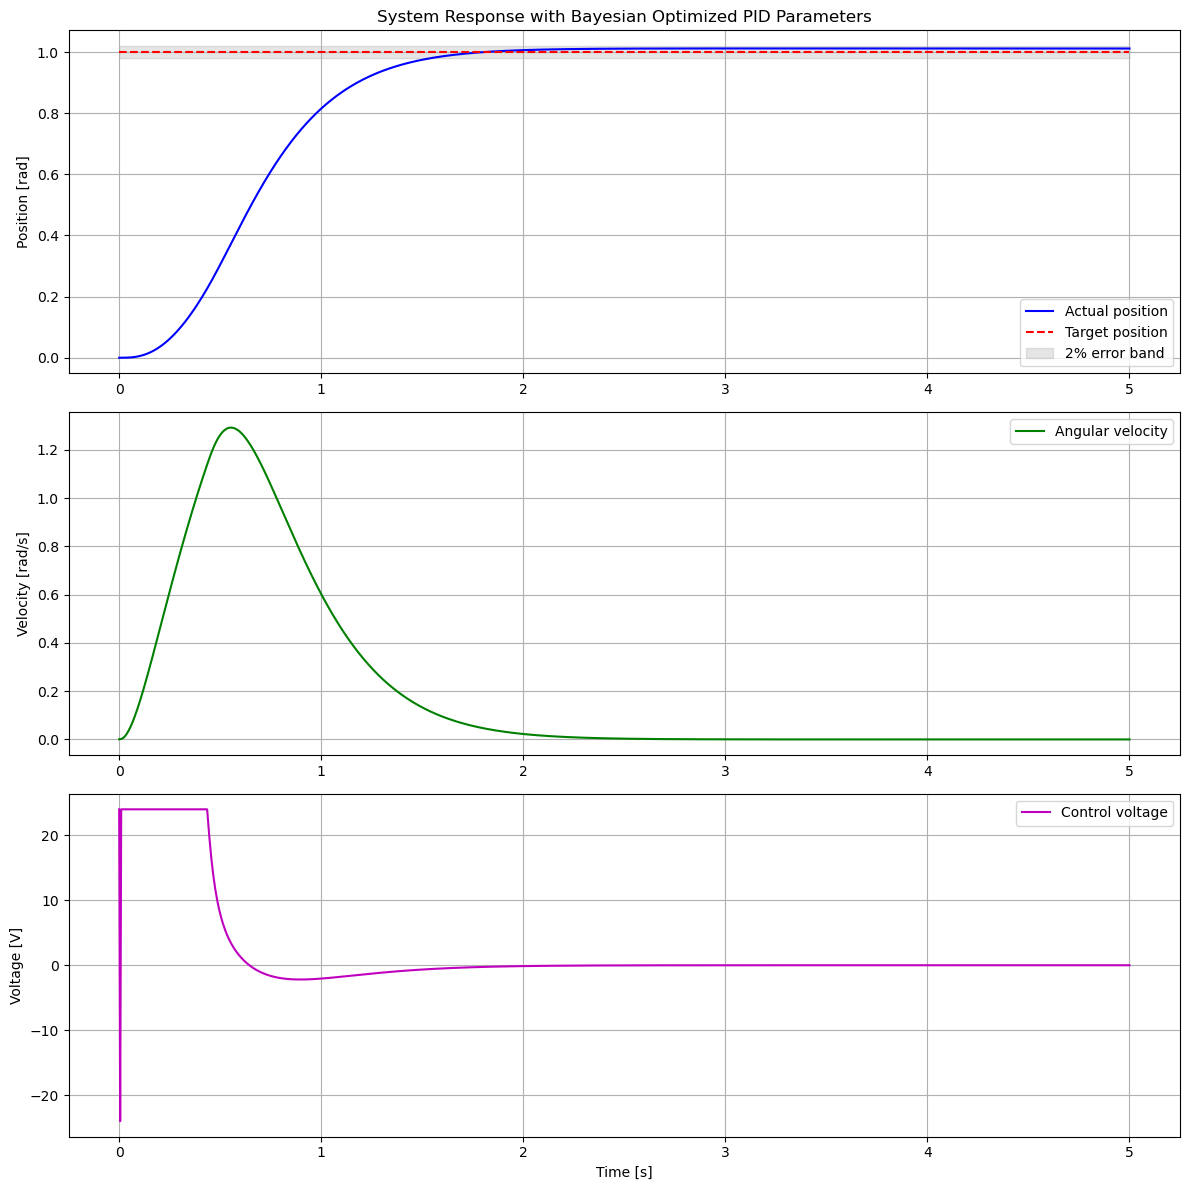

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# DCMotor class remains the same

# CascadedPIDController class remains the same

# Simulate system function remains the same

def objective(params):
    try:
        t, pos, vel, v = simulate_system(params)
        
        pos_ref = 1.0
        pos_error = pos_ref - pos
        
        pos_ise = np.sum(pos_error**2)
        vel_smoothness = np.sum(np.diff(vel)**2)
        control_effort = np.sum(v**2)
        steady_state_error = np.abs(np.mean(pos_error[-100:]))
        overshoot = np.max(np.maximum(pos - pos_ref, 0))
        
        cost = (2.0 * pos_ise + 
                500.0 * steady_state_error +
                10.0 * overshoot + 
                0.01 * vel_smoothness +
                0.001 * control_effort)
        
        return -cost  # Negative because we want to maximize the acquisition function
    except:
        return -1e6  # Return a large negative value if simulation fails

def expected_improvement(X, X_sample, Y_sample, gpr, xi=0.01):
    mu, sigma = gpr.predict(X.reshape(1, -1), return_std=True)
    
    mu_sample_opt = np.max(Y_sample)
    
    with np.errstate(divide='warn'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
        
    return ei

def bayesian_optimization(n_iterations=50, n_initial=5):
    # Define bounds
    bounds = np.array([
        [0.1, 20.0],  # kp_pos
        [0.0, 10.0],  # ki_pos
        [0.0, 10.0],  # kd_pos
        [0.1, 20.0],  # kp_vel
        [0.0, 10.0],  # ki_vel
        [0.0, 10.0],  # kd_vel
    ])
    
    # Initial random samples
    X_sample = np.random.uniform(bounds[:, 0], bounds[:, 1], 
                               size=(n_initial, bounds.shape[0]))
    Y_sample = np.array([objective(x) for x in X_sample])
    
    # Gaussian Process with Matérn kernel
    kernel = Matern(nu=2.5)
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    
    # Optimization iterations
    for i in range(n_iterations):
        # Fit GP
        gpr.fit(X_sample, Y_sample)
        
        # Generate random candidates
        X_candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(100, bounds.shape[0]))
        
        # Find best candidate using EI
        ei_values = [expected_improvement(x, X_sample, Y_sample, gpr) for x in X_candidates]
        next_sample = X_candidates[np.argmax(ei_values)]
        
        # Evaluate objective at new point
        next_objective = objective(next_sample)
        
        # Add new sample
        X_sample = np.vstack((X_sample, next_sample))
        Y_sample = np.append(Y_sample, next_objective)
        
        if i % 10 == 0:
            print(f"Iteration {i}: Best score = {np.max(Y_sample)}")
    
    # Return best parameters
    best_idx = np.argmax(Y_sample)
    return X_sample[best_idx]


# Run Bayesian optimization
print("Starting Bayesian optimization...")
optimized_params = bayesian_optimization(n_iterations=100, n_initial=20)

# Print results and plot
print("\nOptimal PID parameters:")
print("Position loop:")
print(f"Kp = {optimized_params[0]:.3f}")
print(f"Ki = {optimized_params[1]:.3f}")
print(f"Kd = {optimized_params[2]:.3f}")
print("\nVelocity loop:")
print(f"Kp = {optimized_params[3]:.3f}")
print(f"Ki = {optimized_params[4]:.3f}")
print(f"Kd = {optimized_params[5]:.3f}")

# Simulate with optimal parameters
t, pos, vel, v = simulate_system(optimized_params)

# Calculate performance metrics
pos_ref = 1.0
error = pos_ref - pos
steady_state_err = np.abs(np.mean(error[-100:]))
overshoot = np.max(np.maximum(pos - pos_ref, 0)) * 100
settling_time = None
settled_threshold = 0.02

for i in range(len(t)):
    if abs(pos[i] - pos_ref) <= settled_threshold * pos_ref:
        if all(abs(pos[j] - pos_ref) <= settled_threshold * pos_ref 
               for j in range(i, min(i + 100, len(pos)))):
            settling_time = t[i]
            break

print(f"\nSystem performance metrics:")
print(f"Steady-state error = {steady_state_err:.6f}")
print(f"Overshoot = {overshoot:.2f}%")
if settling_time:
    print(f"2% settling time = {settling_time:.2f} seconds")
else:
    print("System did not reach steady state within simulation time")

# Plot results
plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1)
plt.plot(t, pos, 'b-', label='Actual position')
plt.plot(t, np.ones_like(t), 'r--', label='Target position')
plt.fill_between(t, 
                np.ones_like(t) * (1 + 0.02),
                np.ones_like(t) * (1 - 0.02),
                color='gray', alpha=0.2, label='2% error band')
plt.grid(True)
plt.legend()
plt.ylabel('Position [rad]')
plt.title('System Response with Bayesian Optimized PID Parameters')

plt.subplot(3, 1, 2)
plt.plot(t, vel, 'g-', label='Angular velocity')
plt.grid(True)
plt.legend()
plt.ylabel('Velocity [rad/s]')

plt.subplot(3, 1, 3)
plt.plot(t, v, 'm-', label='Control voltage')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')

plt.tight_layout()
plt.show()


## A more complex 2D quadrotor example

Note: This may not be a very good example.

### L-BFGS optimization

Optm completed in 27.47s.
Optimized weight params:
Q = [6.28134732 8.0497008  6.25239795 8.1423226  9.02643211 7.30731227]
R = 0.1

System performance metrics for optimized LQR:
Settling time (2%) = 4.46 seconds
Max overshoot = -20.10%
Final state error = 0.027282

System performance metrics for manually tuned LQR:
Settling time (2%) = 2.51 seconds
Max overshoot = -8.34%
Final state error = 0.000778


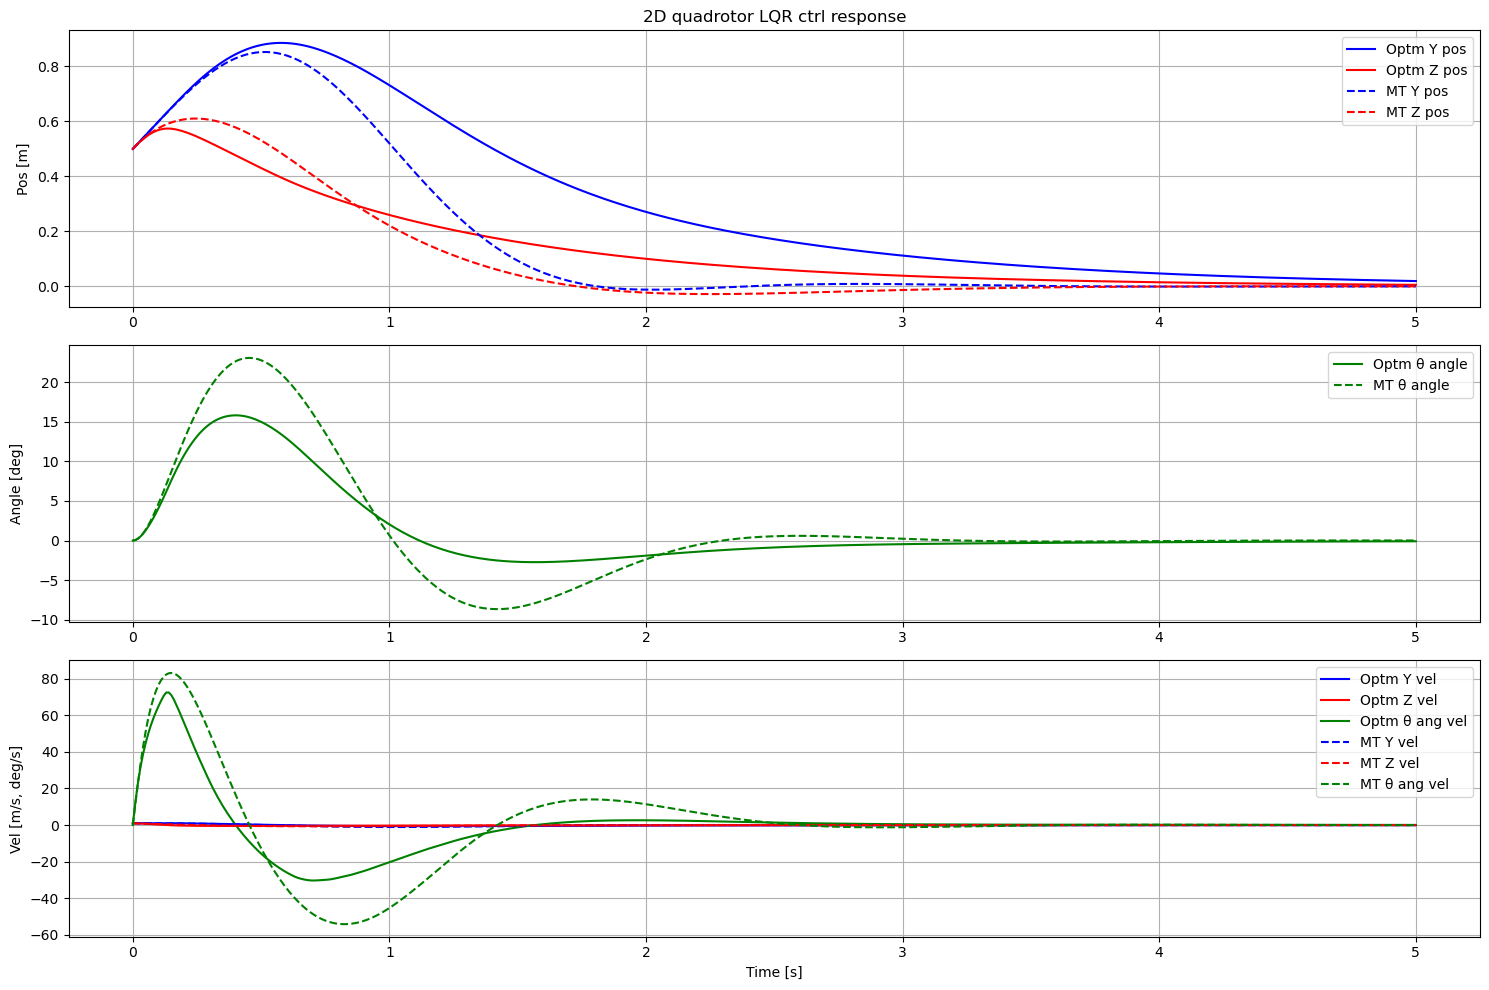

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import time


class Quadrotor2D:
    def __init__(self):
        self.g = 9.81
        self.m = 1
        self.a = 0.25
        self.I = 0.0625

        self.n_x = 6  # [y, z, theta, ydot, zdot, thetadot]
        self.n_u = 2  # [u1, u2]

        # Input limits
        self.umin = 0
        self.umax = 5.5

    def continuous_dynamics(self, t, x, u):
        theta = x[2]
        ydot = x[3]
        zdot = x[4]
        thetadot = x[5]
        u0 = u[0]
        u1 = u[1]

        xdot = np.array(
            [
                ydot,
                zdot,
                thetadot,
                -np.sin(theta) * (u0 + u1) / self.m,
                -self.g + np.cos(theta) * (u0 + u1) / self.m,
                self.a * (u0 - u1) / self.I,
            ]
        )
        return xdot

    def get_linear_system(self):
        A = np.zeros((6, 6))
        A[:3, 3:] = np.eye(3)
        A[3, 2] = -self.g

        B = np.zeros((6, 2))
        B[4, 0] = 1 / self.m
        B[4, 1] = 1 / self.m
        B[5, 0] = self.a / self.I
        B[5, 1] = -self.a / self.I

        return A, B

    def compute_lqr_K(self, Q, R):
        A, B = self.get_linear_system()
        S = solve_continuous_are(A, B, Q, R)
        K = -np.linalg.inv(R) @ B.T @ S
        return K

    def u_equilibrium(self):
        # Equilibrium input
        return np.array([self.m * self.g / 2, self.m * self.g / 2])


def simulate_response(quad, K, x0, t_span, t_eval):
    # Simulate closed-loop system response
    def closed_loop_dynamics(t, x):
        u_eq = quad.u_equilibrium()
        u = u_eq + K @ x
        u = np.clip(u, quad.umin, quad.umax)
        return quad.continuous_dynamics(t, x, u)

    sol = solve_ivp(closed_loop_dynamics, t_span, x0, t_eval=t_eval, method="RK45")
    return sol.t, sol.y


def optm_eval_performance(params):
    # Unpack optimization params
    q_y, q_z, q_theta, q_ydot, q_zdot, q_thetadot, r = params

    # Build weight matrix
    Q = np.diag([q_y, q_z, q_theta, q_ydot, q_zdot, q_thetadot])
    R = r * np.eye(2)

    quad = Quadrotor2D()
    K = quad.compute_lqr_K(Q, R)

    # Define multiple initial conditions for testing
    initial_conditions = [
        np.array([0.5, -0.5, 0.2, 0, 0, 0]),  # Position offset
        np.array([0, 0, 0, 0.5, -0.5, 0.2]),  # Velocity offset
        np.array([0.5, 0.5, 0.1, 1, 1, 0.1]),  # Mixed offset
        np.array([-0.5, 0.8, 0, 0.4, 0.3, -0.1]),  # Mixed offset
    ]

    t_eval = np.linspace(0, 5, 500)
    total_cost = 0

    for x0 in initial_conditions:
        t, x = simulate_response(quad, K, x0, (0, 5), t_eval)

        # Compute performance metrics
        state_error = np.sum(x**2, axis=0)  # State error squared sum
        settling_time = 5  # Default max value

        # 2% settling time
        threshold = 0.02 * np.linalg.norm(x0)
        for i in range(len(t)):
            if np.all(np.abs(x[:, i:]) < threshold):
                settling_time = t[i]
                break

        overshoot = np.max(np.abs(x)) / np.linalg.norm(x0) - 1

        cost = (
            50 * np.sum(state_error)  # State error
            + 50 * settling_time  # Settling time
            + 10 * overshoot  # Overshoot
            + 0.1 * np.sum(x[-1] ** 2)
        )  # Final state error

        total_cost += cost

    return total_cost


# Formulate optimization problem
initial_guess = [10, 10, 1, 1, 1, 1, 1]
bounds = [(0.1, 20.0)] * 7

# Optimization
start_time = time.time()
result = minimize(
    optm_eval_performance,
    initial_guess,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 10000},
)
print(f"Optm completed in {time.time() - start_time:.2f}s.")

# Get optimized params
optimized_params = result.x
print("Optimized weight params:")
print(f"Q = {optimized_params[:6]}")
print(f"R = {optimized_params[6]}")

# Simulate using optimized and baseline params
q_y, q_z, q_theta, q_ydot, q_zdot, q_thetadot, r = optimized_params
Q_optm = np.diag([q_y, q_z, q_theta, q_ydot, q_zdot, q_thetadot])
R_optm = r * np.eye(2)
Q_manual = np.diag([10, 10, 1, 1, 1, 1])
R_manual = np.eye(2)

quad = Quadrotor2D()
K_optm = quad.compute_lqr_K(Q_optm, R_optm)
K_manual = quad.compute_lqr_K(Q_manual, R_manual)

# x0 = np.array([0.5, -0.5, 0.2, 0, 0, 0])
x0 = np.array([0.5, 0.5, 0, 1, 1, 0])
t_eval = np.linspace(0, 5, 500)
t, x_optm = simulate_response(quad, K_optm, x0, (0, 5), t_eval)
_, x_manual = simulate_response(quad, K_manual, x0, (0, 5), t_eval)

# Compute performance metrics for optimized LQR and manually tuned LQR
settling_threshold = 0.02 * np.linalg.norm(x0)
settling_time_optm = 5
settling_time_manual = 5
for i in range(len(t)):
    if np.all(np.abs(x_optm[:, i:]) < settling_threshold):
        settling_time_optm = t[i]
        break
for i in range(len(t)):
    if np.all(np.abs(x_manual[:, i:]) < settling_threshold):
        settling_time_manual = t[i]
        break
max_overshoot_optm = np.max(np.abs(x_optm)) / np.linalg.norm(x0) - 1
final_error_optm = np.linalg.norm(x_optm[:, -1])
max_overshoot_manual = np.max(np.abs(x_manual)) / np.linalg.norm(x0) - 1
final_error_manual = np.linalg.norm(x_manual[:, -1])
print("\nSystem performance metrics for optimized LQR:")
print(f"Settling time (2%) = {settling_time_optm:.2f} seconds")
print(f"Max overshoot = {max_overshoot_optm*100:.2f}%")
print(f"Final state error = {final_error_optm:.6f}")
print("\nSystem performance metrics for manually tuned LQR:")
print(f"Settling time (2%) = {settling_time_manual:.2f} seconds")
print(f"Max overshoot = {max_overshoot_manual*100:.2f}%")
print(f"Final state error = {final_error_manual:.6f}")

# Plot results
plt.figure(figsize=(15, 10))

# Position response
plt.subplot(3, 1, 1)
plt.plot(t, x_optm[0], "b-", label="Optm Y pos")
plt.plot(t, x_optm[1], "r-", label="Optm Z pos")
plt.plot(t, x_manual[0], "b--", label="MT Y pos")
plt.plot(t, x_manual[1], "r--", label="MT Z pos")
plt.grid(True)
plt.legend()
plt.ylabel("Pos [m]")
plt.title("2D quadrotor LQR ctrl response")

# Attitude response
plt.subplot(3, 1, 2)
plt.plot(t, np.rad2deg(x_optm[2]), "g-", label="Optm θ angle")
plt.plot(t, np.rad2deg(x_manual[2]), "g--", label="MT θ angle")
plt.grid(True)
plt.legend()
plt.ylabel("Angle [deg]")

# Velocity response
plt.subplot(3, 1, 3)
plt.plot(t, x_optm[3], "b-", label="Optm Y vel")
plt.plot(t, x_optm[4], "r-", label="Optm Z vel")
plt.plot(t, np.rad2deg(x_optm[5]), "g-", label="Optm θ ang vel")
plt.plot(t, x_manual[3], "b--", label="MT Y vel")
plt.plot(t, x_manual[4], "r--", label="MT Z vel")
plt.plot(t, np.rad2deg(x_manual[5]), "g--", label="MT θ ang vel")
plt.grid(True)
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Vel [m/s, deg/s]")

plt.tight_layout()
plt.show()

### Beyesian optimization

Starting Bayesian optimization...
Iteration 0: Best score = -22798.6098603876
Iteration 10: Best score = -22750.20479294411
Iteration 20: Best score = -21731.572676667278
Iteration 30: Best score = -21731.572676667278
Iteration 40: Best score = -21731.572676667278
Iteration 50: Best score = -21731.572676667278
Iteration 60: Best score = -21731.572676667278
Iteration 70: Best score = -21731.572676667278
Iteration 80: Best score = -21731.572676667278
Iteration 90: Best score = -21731.572676667278
Optimization completed in 7.35s

Optimized weight parameters:
Q_y = 18.415
Q_z = 11.558
Q_theta = 2.678
Q_ydot = 18.677
Q_zdot = 16.734
Q_thetadot = 13.737
R = 0.897

System performance metrics for optimized LQR:
Settling time (2%) = 4.01 seconds
Max overshoot = -11.86%
Final state error = 0.022190

System performance metrics for manually tuned LQR:
Settling time (2%) = 2.51 seconds
Max overshoot = -8.34%
Final state error = 0.000778


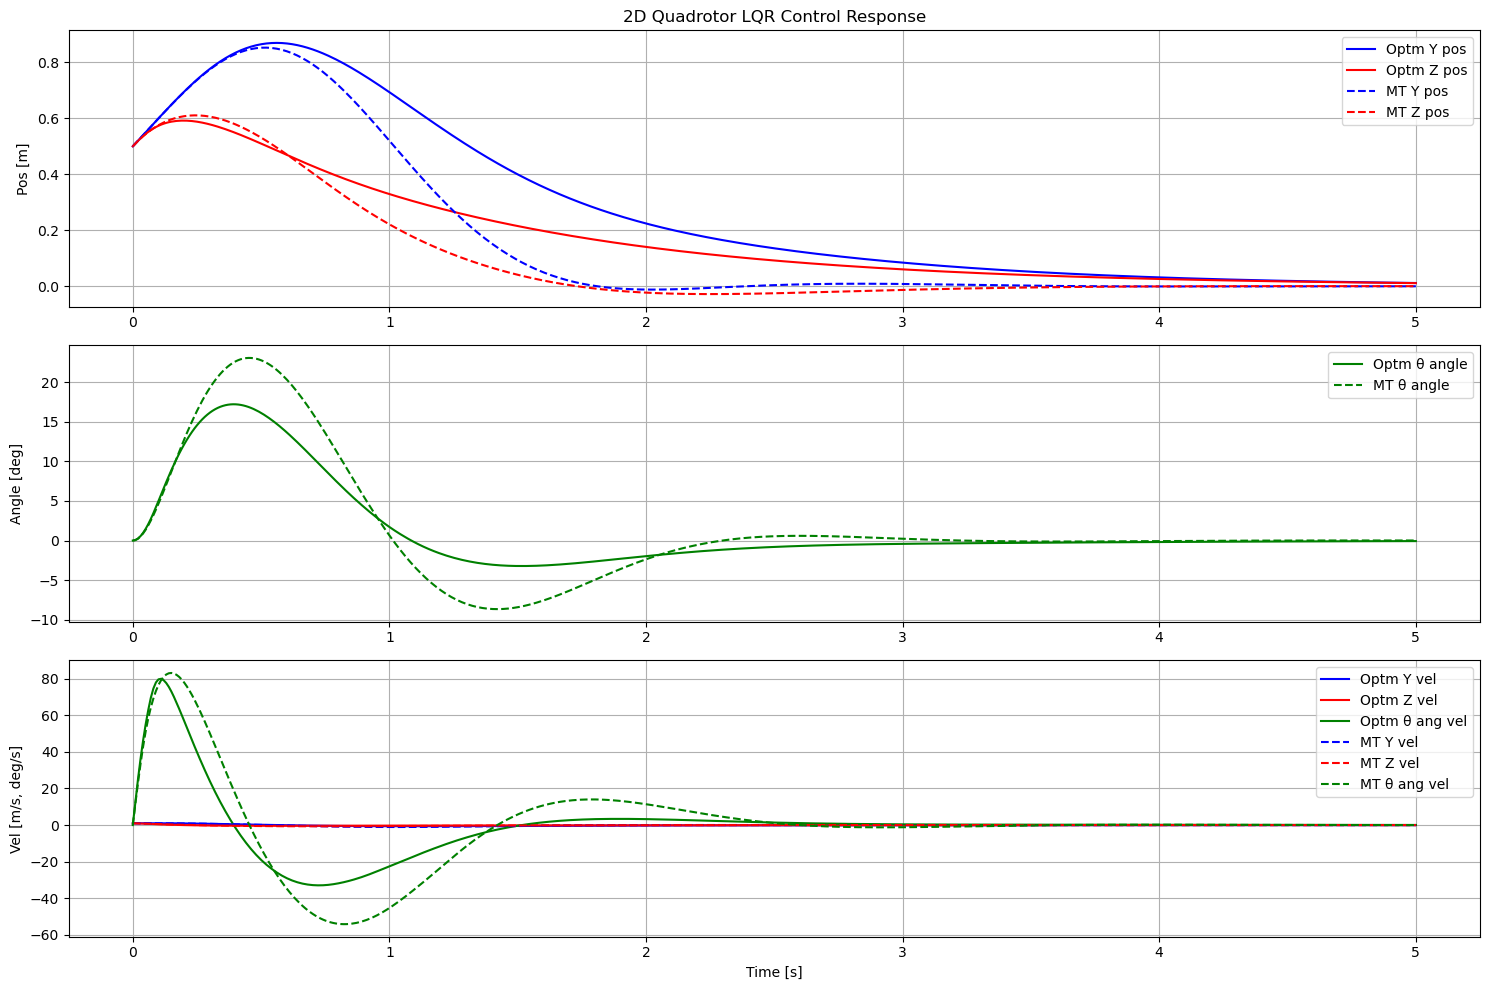

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import time
import warnings
warnings.filterwarnings('ignore')

# Quadrotor2D class remains the same

# simulate_response function remains the same

def objective(params):
    try:
        q_y, q_z, q_theta, q_ydot, q_zdot, q_thetadot, r = params

        Q = np.diag([q_y, q_z, q_theta, q_ydot, q_zdot, q_thetadot])
        R = r * np.eye(2)

        quad = Quadrotor2D()
        K = quad.compute_lqr_K(Q, R)

        initial_conditions = [
            np.array([0.5, -0.5, 0.2, 0, 0, 0]),
            np.array([0, 0, 0, 0.5, -0.5, 0.2]),
            np.array([0.5, 0.5, 0.1, 1, 1, 0.1]),
            np.array([-0.5, 0.8, 0, 0.4, 0.3, -0.1]),
        ]

        t_eval = np.linspace(0, 5, 500)
        total_cost = 0

        for x0 in initial_conditions:
            t, x = simulate_response(quad, K, x0, (0, 5), t_eval)

            state_error = np.sum(x**2, axis=0)
            settling_time = 5

            threshold = 0.02 * np.linalg.norm(x0)
            for i in range(len(t)):
                if np.all(np.abs(x[:, i:]) < threshold):
                    settling_time = t[i]
                    break

            overshoot = np.max(np.abs(x)) / np.linalg.norm(x0) - 1

            cost = (
                50 * np.sum(state_error)
                + 50 * settling_time
                + 10 * overshoot
                + 0.1 * np.sum(x[-1] ** 2)
            )

            total_cost += cost

        return -total_cost  # Negative because we want to maximize EI
    except:
        return -1e6

def expected_improvement(X, X_sample, Y_sample, gpr, xi=0.01):
    mu, sigma = gpr.predict(X.reshape(1, -1), return_std=True)
    
    mu_sample_opt = np.max(Y_sample)
    
    with np.errstate(divide='warn'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
        
    return ei

def bayesian_optimization(n_iterations=50, n_initial=20):
    bounds = np.array([
        [0.0, 20.0],  # q_y
        [0.0, 20.0],  # q_z
        [0.0, 20.0],  # q_theta
        [0.0, 20.0],  # q_ydot
        [0.0, 20.0],  # q_zdot
        [0.0, 20.0],  # q_thetadot
        [0.0, 20.0],  # r
    ])
    
    X_sample = np.random.uniform(bounds[:, 0], bounds[:, 1], 
                               size=(n_initial, bounds.shape[0]))
    Y_sample = np.array([objective(x) for x in X_sample])
    
    kernel = Matern(nu=2.5)
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    
    for i in range(n_iterations):
        gpr.fit(X_sample, Y_sample)
        
        X_candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], 
                                       size=(100, bounds.shape[0]))
        
        ei_values = [expected_improvement(x, X_sample, Y_sample, gpr) 
                    for x in X_candidates]
        next_sample = X_candidates[np.argmax(ei_values)]
        
        next_objective = objective(next_sample)
        
        X_sample = np.vstack((X_sample, next_sample))
        Y_sample = np.append(Y_sample, next_objective)
        
        if i % 10 == 0:
            print(f"Iteration {i}: Best score = {np.max(Y_sample)}")
    
    best_idx = np.argmax(Y_sample)
    return X_sample[best_idx]

# Run Bayesian optimization
print("Starting Bayesian optimization...")
start_time = time.time()
optimized_params = bayesian_optimization(n_iterations=100, n_initial=20)
print(f"Optimization completed in {time.time() - start_time:.2f}s")

# Print optimized parameters
print("\nOptimized weight parameters:")
print(f"Q_y = {optimized_params[0]:.3f}")
print(f"Q_z = {optimized_params[1]:.3f}")
print(f"Q_theta = {optimized_params[2]:.3f}")
print(f"Q_ydot = {optimized_params[3]:.3f}")
print(f"Q_zdot = {optimized_params[4]:.3f}")
print(f"Q_thetadot = {optimized_params[5]:.3f}")
print(f"R = {optimized_params[6]:.3f}")

# Compare optimized vs manual tuning
Q_optm = np.diag(optimized_params[:6])
R_optm = optimized_params[6] * np.eye(2)
Q_manual = np.diag([10, 10, 1, 1, 1, 1])
R_manual = np.eye(2)

quad = Quadrotor2D()
K_optm = quad.compute_lqr_K(Q_optm, R_optm)
K_manual = quad.compute_lqr_K(Q_manual, R_manual)

x0 = np.array([0.5, 0.5, 0, 1, 1, 0])
t_eval = np.linspace(0, 5, 500)
t, x_optm = simulate_response(quad, K_optm, x0, (0, 5), t_eval)
_, x_manual = simulate_response(quad, K_manual, x0, (0, 5), t_eval)

# Performance metrics
settling_threshold = 0.02 * np.linalg.norm(x0)
settling_time_optm = 5
settling_time_manual = 5

for i in range(len(t)):
    if np.all(np.abs(x_optm[:, i:]) < settling_threshold):
        settling_time_optm = t[i]
        break
for i in range(len(t)):
    if np.all(np.abs(x_manual[:, i:]) < settling_threshold):
        settling_time_manual = t[i]
        break

max_overshoot_optm = np.max(np.abs(x_optm)) / np.linalg.norm(x0) - 1
final_error_optm = np.linalg.norm(x_optm[:, -1])
max_overshoot_manual = np.max(np.abs(x_manual)) / np.linalg.norm(x0) - 1
final_error_manual = np.linalg.norm(x_manual[:, -1])

print("\nSystem performance metrics for optimized LQR:")
print(f"Settling time (2%) = {settling_time_optm:.2f} seconds")
print(f"Max overshoot = {max_overshoot_optm*100:.2f}%")
print(f"Final state error = {final_error_optm:.6f}")
print("\nSystem performance metrics for manually tuned LQR:")
print(f"Settling time (2%) = {settling_time_manual:.2f} seconds")
print(f"Max overshoot = {max_overshoot_manual*100:.2f}%")
print(f"Final state error = {final_error_manual:.6f}")

# Plot results
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(t, x_optm[0], "b-", label="Optm Y pos")
plt.plot(t, x_optm[1], "r-", label="Optm Z pos")
plt.plot(t, x_manual[0], "b--", label="MT Y pos")
plt.plot(t, x_manual[1], "r--", label="MT Z pos")
plt.grid(True)
plt.legend()
plt.ylabel("Pos [m]")
plt.title("2D Quadrotor LQR Control Response")

plt.subplot(3, 1, 2)
plt.plot(t, np.rad2deg(x_optm[2]), "g-", label="Optm θ angle")
plt.plot(t, np.rad2deg(x_manual[2]), "g--", label="MT θ angle")
plt.grid(True)
plt.legend()
plt.ylabel("Angle [deg]")

plt.subplot(3, 1, 3)
plt.plot(t, x_optm[3], "b-", label="Optm Y vel")
plt.plot(t, x_optm[4], "r-", label="Optm Z vel")
plt.plot(t, np.rad2deg(x_optm[5]), "g-", label="Optm θ ang vel")
plt.plot(t, x_manual[3], "b--", label="MT Y vel")
plt.plot(t, x_manual[4], "r--", label="MT Z vel")
plt.plot(t, np.rad2deg(x_manual[5]), "g--", label="MT θ ang vel")
plt.grid(True)
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Vel [m/s, deg/s]")

plt.tight_layout()
plt.show()